### Preliminaries

In [ ]:
import time
from operator import itemgetter

import matplotlib.pyplot as plt
import mlflow
import mlflow.xgboost
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

### Prepare dataset


In [2]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=201
)
X.head(n=5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# You will use NUM_MODELS as a benchmark to compare performance
# across sequential and parallel implementations.

NUM_MODELS = 20

In [4]:
def train_and_score_model(
    train_set: pd.DataFrame,
    test_set: pd.DataFrame,
    train_labels: pd.Series,
    test_labels: pd.Series,
    n_estimators: int,
) -> tuple[int, float]:
    start_time = time.time()  # measure wall time for single model training

    model = XGBClassifier(n_estimators=n_estimators, random_state=201, eval_metric="logloss")
    model.fit(train_set, train_labels)
    y_pred = model.predict(test_set)
    score = accuracy_score(test_labels, y_pred)

    time_delta = time.time() - start_time
    print(f"n_estimators={n_estimators}, accuracy={score:.4f}, took: {time_delta:.2f} seconds")

    return n_estimators, score

In [5]:
def run_sequential(n_models: int) -> list[tuple[int, float]]:
    return [
        train_and_score_model(
            train_set=X_train,
            test_set=X_test,
            train_labels=y_train,
            test_labels=y_test,
            n_estimators=8 + 4 * j,
        )
        for j in range(n_models)
    ]

`run_sequential` trains `NUM_MODELS` XGBClassifiers one at a time, incrementing `n_estimators` by 4 each run (8, 12, 16, ...). It returns a list of `(n_estimators, accuracy)` tuples stored in `seq_scores`.

In [6]:
%%time

seq_scores = run_sequential(n_models=NUM_MODELS)

n_estimators=8, accuracy=0.9737, took: 0.03 seconds
n_estimators=12, accuracy=0.9649, took: 0.02 seconds
n_estimators=16, accuracy=0.9737, took: 0.02 seconds
n_estimators=20, accuracy=0.9649, took: 0.02 seconds
n_estimators=24, accuracy=0.9737, took: 0.02 seconds
n_estimators=28, accuracy=0.9737, took: 0.03 seconds
n_estimators=32, accuracy=0.9737, took: 0.03 seconds
n_estimators=36, accuracy=0.9737, took: 0.03 seconds
n_estimators=40, accuracy=0.9737, took: 0.03 seconds
n_estimators=44, accuracy=0.9737, took: 0.03 seconds
n_estimators=48, accuracy=0.9737, took: 0.03 seconds
n_estimators=52, accuracy=0.9737, took: 0.04 seconds
n_estimators=56, accuracy=0.9737, took: 0.03 seconds
n_estimators=60, accuracy=0.9737, took: 0.04 seconds
n_estimators=64, accuracy=0.9737, took: 0.04 seconds
n_estimators=68, accuracy=0.9737, took: 0.04 seconds
n_estimators=72, accuracy=0.9737, took: 0.04 seconds
n_estimators=76, accuracy=0.9825, took: 0.04 seconds
n_estimators=80, accuracy=0.9825, took: 0.04 se

In [7]:
### Analyze results

In [8]:
seq_best = max(seq_scores, key=itemgetter(1))
print(f"Best model (sequential): accuracy={seq_best[1]:.4f}, n_estimators={seq_best[0]}")

Best model (sequential): accuracy=0.9825, n_estimators=76


Looking at the results of training, make a note on how long training NUM_MODELS sequentially took. Continue on to the next section to learn about how to improve runtime by distributing this task.

### Parallel implementation
In contrast to the previous approach, you will now utilize all available resources to train these models in parallel. Ray will automatically detect the number of cores on your computer or the amount of resources in a cluster to distribute each defined task.

The diagram below offers an intuition for how tasks are assigned and executed in a parallel approach. You will notice that this introduces a scheduler which is responsible for managing incoming requests, assigning nodes, and detecting available resources.

In [9]:
!uv add ray xgboost mlflow ipywidgets

Resolved 153 packages in 1ms
Audited 147 packages in 6ms


In [10]:
import ray

if ray.is_initialized:
    ray.shutdown()

ray.init()

2026-03-28 09:28:53,060	INFO worker.py:2023 -- Started a local Ray instance.
e:\NEU Stuff\IE7374\MLOPs\.venv\Lib\site-packages\ray\_private\worker.py:2062: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.12.12
Ray version:,2.52.1


Begin by running ray.init() to start a fresh Ray cluster and take a look at some useful information:

Python version
Ray version
Link to Ray Dashboard: an observability tool that provides insight into what Ray is doing via helpful metrics and charts

Workers use ray.put() to place objects and use ray.get() to retrieve them from each node's object store. These object stores form the shared distributed memory that makes objects available across a Ray cluster.

In a distributed system, object references are pointers to objects in memory. Object references can be used to access objects that are stored on different machines, allowing them to communicate with each other and share data.

In [11]:
X_train_ref = ray.put(X_train)
X_test_ref = ray.put(X_test)
y_train_ref = ray.put(y_train)
y_test_ref = ray.put(y_test)

By placing the training and testing data into Ray's object store, these objects are now available to all remote tasks and actors in the cluster.

Coding Exercise

To practice working with object references, use the cell below to:

Print what X_train_ref looks like.
Retrieve X_train by using ray.get() on the object reference.
An example Object Reference looks like this:

In [12]:
### SAMPLE IMPLEMENTATION ###

# print the object reference
print(X_train_ref)

# inspect the in-memory object
ray.get(X_train_ref)

ObjectRef(00ffffffffffffffffffffffffffffffffffffff0100000001e1f505)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
349,11.950,14.96,77.23,426.7,0.11580,0.12060,0.01171,0.01787,0.2459,0.06581,...,12.810,17.72,83.09,496.2,0.12930,0.18850,0.03122,0.04766,0.3124,0.07590
462,14.400,26.99,92.25,646.1,0.06995,0.05223,0.03476,0.01737,0.1707,0.05433,...,15.400,31.98,100.40,734.6,0.10170,0.14600,0.14720,0.05563,0.2345,0.06464
172,15.460,11.89,102.50,736.9,0.12570,0.15550,0.20320,0.10970,0.1966,0.07069,...,18.790,17.04,125.00,1102.0,0.15310,0.35830,0.58300,0.18270,0.3216,0.10100
526,13.460,18.75,87.44,551.1,0.10750,0.11380,0.04201,0.03152,0.1723,0.06317,...,15.350,25.16,101.90,719.8,0.16240,0.31240,0.26540,0.14270,0.3518,0.08665
108,22.270,19.67,152.80,1509.0,0.13260,0.27680,0.42640,0.18230,0.2556,0.07039,...,28.400,28.01,206.80,2360.0,0.17010,0.69970,0.96080,0.29100,0.4055,0.09789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,13.820,24.49,92.33,595.9,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,16.010,32.94,106.00,788.0,0.17940,0.39660,0.33810,0.15210,0.3651,0.11830
353,15.080,25.74,98.00,716.6,0.10240,0.09769,0.12350,0.06553,0.1647,0.06464,...,18.510,33.22,121.20,1050.0,0.16600,0.23560,0.40290,0.15260,0.2654,0.09438
568,7.760,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.00000,0.00000,0.2871,0.07039
553,9.333,21.94,59.01,264.0,0.09240,0.05605,0.03996,0.01282,0.1692,0.06576,...,9.845,25.05,62.86,295.8,0.11030,0.08298,0.07993,0.02564,0.2435,0.07393


### Implement function to train and score model

In [13]:
@ray.remote
def train_and_score_model(
    train_set_ref: pd.DataFrame,
    test_set_ref: pd.DataFrame,
    train_labels_ref: pd.Series,
    test_labels_ref: pd.Series,
    n_estimators: int,
) -> tuple[int, float]:
    import time
    from sklearn.metrics import accuracy_score
    from xgboost import XGBClassifier

    start_time = time.time()  # measure wall time for single model training

    model = XGBClassifier(n_estimators=n_estimators, random_state=201, eval_metric="logloss")
    model.fit(train_set_ref, train_labels_ref)
    y_pred = model.predict(test_set_ref)
    score = accuracy_score(test_labels_ref, y_pred)

    time_delta = time.time() - start_time
    print(f"n_estimators={n_estimators}, accuracy={score:.4f}, took: {time_delta:.2f} seconds")

    return n_estimators, score

`train_and_score_model` is identical to the sequential version but decorated with `@ray.remote`, telling Ray to execute it as a distributed task.

In [14]:
def run_parallel(n_models: int) -> list[tuple[int, float]]:
    results_ref = [
        train_and_score_model.remote(
            train_set_ref=X_train_ref,
            test_set_ref=X_test_ref,
            train_labels_ref=y_train_ref,
            test_labels_ref=y_test_ref,
            n_estimators=8 + 4 * j,
        )
        for j in range(n_models)
    ]
    return ray.get(results_ref)

`run_parallel` mirrors `run_sequential` with three changes:

1. `.remote()` suffix — submits each model training as a non-blocking Ray task
2. `results_ref` — holds object references to futures, not actual results
3. `ray.get(results_ref)` — blocks until all tasks complete, then returns `(n_estimators, accuracy)` tuples as `par_scores`

### Run parallel model training

In [15]:
%%time

par_scores = run_parallel(n_models=NUM_MODELS)

(train_and_score_model pid=7412) n_estimators=36, accuracy=0.9737, took: 0.15 seconds
CPU times: total: 156 ms
Wall time: 5.71 s


### Performance Gain with Ray

Ray distributes each model training task across available CPU cores, running all 20 models concurrently rather than one at a time. The parallel run completes significantly faster than the sequential run — the exact speedup depends on the number of cores available on your machine.

### Analyze Results

In [16]:
best = max(par_scores, key=itemgetter(1))
print(f"Best model (parallel): accuracy={best[1]:.4f}, n_estimators={best[0]}")

Best model (parallel): accuracy=0.9825, n_estimators=76


(train_and_score_model pid=30536) n_estimators=32, accuracy=0.9737, took: 0.08 seconds


### Best Model Analysis

In [17]:
best_n_estimators = best[0]
best_model = XGBClassifier(n_estimators=best_n_estimators, random_state=201, eval_metric="logloss")
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=load_breast_cancer().target_names))

Accuracy : 0.9825
F1 Score : 0.9853
ROC AUC  : 0.9942

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        46
      benign       0.99      0.99      0.99        68

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



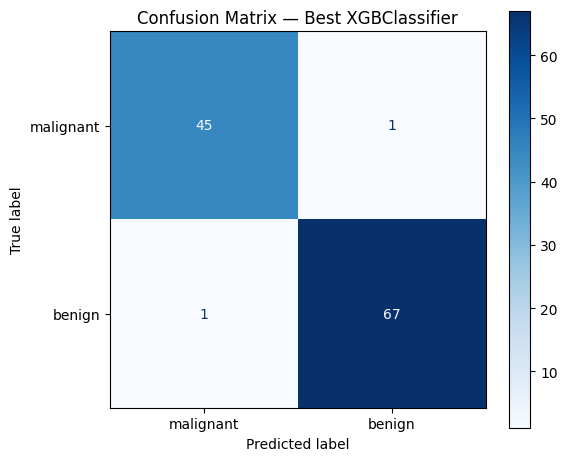

In [18]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=load_breast_cancer().target_names,
    cmap="Blues",
    ax=ax,
)
ax.set_title("Confusion Matrix — Best XGBClassifier")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

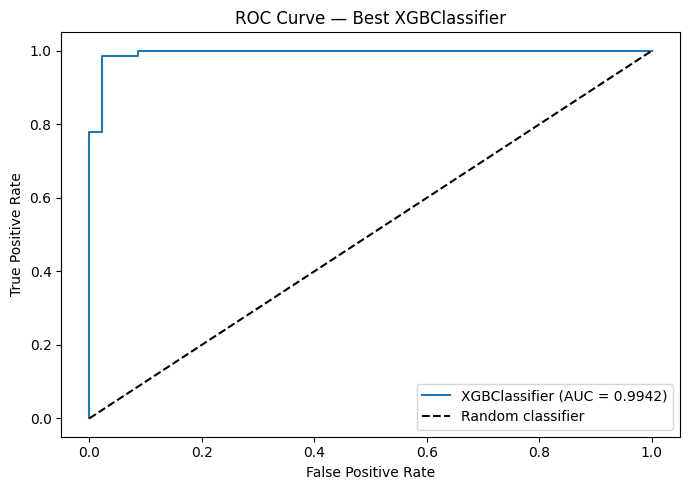

In [19]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"XGBClassifier (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Best XGBClassifier")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

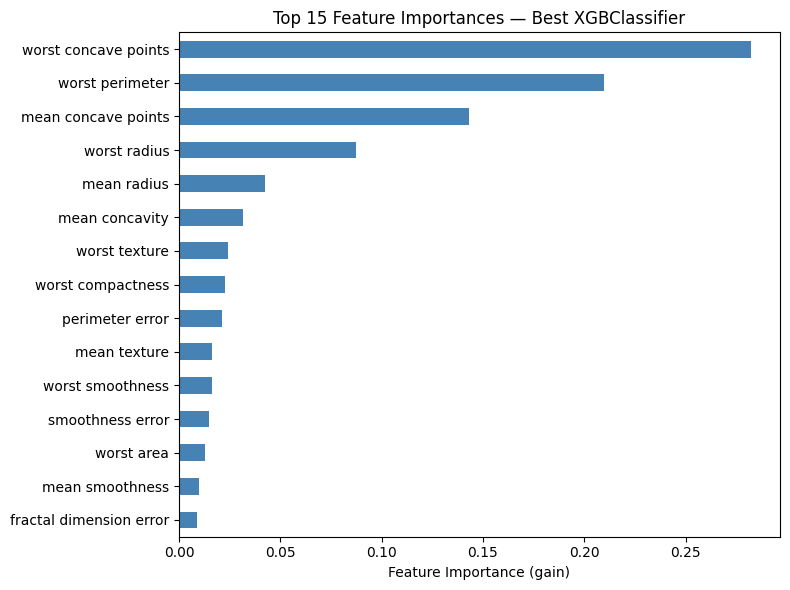

In [20]:
# Feature Importance
feature_names = load_breast_cancer().feature_names
importance = pd.Series(best_model.feature_importances_, index=feature_names).sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 6))
importance.plot(kind="barh", color="steelblue")
plt.xlabel("Feature Importance (gain)")
plt.title("Top 15 Feature Importances — Best XGBClassifier")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

### MLflow Tracking

In [21]:
mlflow.set_experiment("ray-breast-cancer-xgboost")

with mlflow.start_run():
    mlflow.log_params({
        "n_estimators": best_n_estimators,
        "random_state": 42,
        "dataset": "breast_cancer",
        "num_models_searched": NUM_MODELS,
    })
    mlflow.log_metrics({
        "accuracy": accuracy,
        "f1_score": f1,
        "roc_auc": auc,
    })
    mlflow.xgboost.log_model(best_model, name="model")
    mlflow.log_artifact("confusion_matrix.png")
    mlflow.log_artifact("roc_curve.png")
    mlflow.log_artifact("feature_importance.png")
    mlflow.log_artifact("accuracy_vs_estimators.png")

print("MLflow run logged successfully.")

2026/03/28 09:29:02 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/03/28 09:29:02 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/03/28 09:29:02 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/03/28 09:29:02 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/03/28 09:29:02 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/03/28 09:29:02 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/03/28 09:29:03 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/28 09:29:03 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/03/28 09:29:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


MLflow run logged successfully.


### Shutdown

In [22]:
# Shutdown Ray runtime
ray.shutdown()